# PSF Convolution and FWHM Comparison (Document-20160)

This notebook verifies the OpSim empirical combining formula from Xin, Angeli & Ivezić (2016).

The paper shows that for a VonKarman atmospheric PSF convolved with a Gaussian system PSF,
the total FWHM is **not** a simple quadrature sum. Instead (Eqs 4.3–4.4):

$$\mathrm{FWHM_{eff}} = 1.16\,\sqrt{\mathrm{FWHM_{sys}^2} + 1.04\,\mathrm{FWHM_{atm}^2}}$$
$$\mathrm{FWHM_{tot}} = 0.822\,\mathrm{FWHM_{eff}} + 0.052$$

Both components degrade with airmass $X = \sec(z)$:

$$r_0(\lambda, X) = r_0(500, X{=}1)\left(\frac{\lambda}{500}\right)^{6/5} X^{-3/5} \quad\text{(Eq 3.2)}$$
$$\mathrm{FWHM_{sys}}(X) = \mathrm{FWHM_{sys,0}}\; X^{3/5} \quad\text{(Eq 3.6)}$$

**LSST reference parameters (Sec. 2):** L₀ = 30 m, FWHMsys₀ = 0.4″ at zenith/500 nm.

In [1]:
import galsim
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d


eff_wavelengths = {
    'u': 365.0,
    'g': 480.0,
    'r': 622.0,
    'i': 754.0,
    'z': 868.0,
    'y': 973.0,}

sys_eff_wavelengths = {
            "u": 372.354597,
            "g": 480.687954,
            "r": 622.146782,
            "i": 755.898675,
            "z": 867.965175,
            "y": 975.343548,
        }


In [29]:
# --- Baseline parameters (Document-20160, Sec. 2 & 3) ---
# lam       = 600.0  # wavelength [nm], LSST reference
r0_m      = 0.19  # Fried parameter at zenith / 500 nm [m]
L0_m      = 30.0   # outer scale [m], LSST site value (Sec. 2.1)
fwhm_sys0 = np.sqrt(0.30**2 + 0.25**2 + 0.08**2)  # system FWHM at zenith [arcsec] = 0.4"

lam = sys_eff_wavelengths['g']  # reference wavelength for this example [nm]
# sys_lam = sys_eff_wavelengths['g']  # system wavelength for this example [nm]

# Airmass (X = sec(z)); X=1 → zenith, X=2 → z ≈ 60°
# X = 1.2
X = 1.5 #1 / np.cos(np.radians(90 - 29.3))

# Eq 3.2 — r0 scales with airmass (at fixed lam=500nm, (lam/500)^(6/5)=1)
r0_scaled = r0_m * X**(-0.6) * (lam/500)**(6/5)

# Eq 3.6 — system FWHM scales with airmass
fwhm_sys = fwhm_sys0 * X**0.6

# Eq 3.3 — analytic atmospheric FWHM (outer-scale-corrected VonKarman)
# r0 and L0 must be in consistent units; formula uses cm internally
def fwhm_atm_analytic(lam_nm, r0_meters, L0_meters=30.0):
    r0_cm = r0_meters * 100.0
    L0_cm = L0_meters * 100.0
    fwhm0 = 0.976 * 2.063e-2 * (lam_nm / r0_cm)
    outer_scale_corr = np.sqrt(1.0 - 2.183 * (r0_cm / L0_cm)**0.356)
    return fwhm0 * outer_scale_corr

# fwhm_atm_500 = 0.976 * 2.063e-2 * (500 / (r0_m * 100))

fwhm_atm_eq33 = fwhm_atm_analytic(lam, r0_scaled, L0_m)


print(f"Airmass X = {X:.2f}  (zenith angle {np.degrees(np.arccos(1/X)):.1f}°)")
print(f"r0 (scaled)               : {r0_scaled*100:.2f} cm")
print(f"FWHMatm  (Eq 3.3 analytic): {fwhm_atm_eq33:.4f} arcsec")
# print(f"FWHMatm  (Eq 3.2 analytic from FWHM500): {(fwhm_atm_500 * (lam/500)**(-1/5) * X**(3/5) *np.sqrt(1.0 - 2.183 * (r0_scaled * 100 / L0_m / 100)**0.356) ):.4f} arcsec") #* np.sqrt(1.0 - 2.183 * (r0_scaled/ L0_m)**0.356)
print(f"FWHMsys  (Eq 3.6 scaled)  : {fwhm_sys:.4f} arcsec")

# --- GalSim PSF objects at this airmass ---
atm_psf   = galsim.VonKarman(lam=lam, r0=r0_scaled, L0=L0_m)
sys_psf   = galsim.Gaussian(fwhm=fwhm_sys)
total_psf = galsim.Convolve([atm_psf, sys_psf])

Airmass X = 1.50  (zenith angle 48.2°)
r0 (scaled)               : 14.21 cm
FWHMatm  (Eq 3.3 analytic): 0.5597 arcsec
FWHMsys  (Eq 3.6 scaled)  : 0.5084 arcsec


In [30]:
from scipy.optimize import curve_fit
from scipy.special import erf

scale = 0.02   # arcsec/pixel
npix  = 512# 10.24" field of view

def measure_fwhm(profile, npix=512, scale=0.02):
    """Estimate FWHM by interpolating the radial profile to the half-maximum.
    Precision is limited to roughly one pixel (scale)."""
    img = profile.drawImage(nx=npix, ny=npix, scale=scale)
    arr = img.array
    cy, cx = np.unravel_index(arr.argmax(), arr.shape)

    y, x = np.indices(arr.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2) * scale

    r_flat   = r.ravel()
    v_flat   = arr.ravel() / arr.max()
    order    = np.argsort(r_flat)
    r_sorted = r_flat[order]
    v_sorted = v_flat[order]

    half_r = np.interp(0.5, v_sorted[::-1], r_sorted[::-1])
    return 2.0 * half_r


def measure_fwhm_gauss_fit(profile, npix=512, scale=0.02):
    """Fit a pixelized 2D Gaussian to the PSF image and return the FWHM of
    the underlying continuous Gaussian (sub-pixel precision).

    Each pixel's model value is the exact integral of the continuous Gaussian
    over the pixel area:

        model[i,j] = A * [erf((xi - x0 + p/2) / (√2 σ)) - erf((xi - x0 - p/2) / (√2 σ))]
                       * [erf((yi - y0 + p/2) / (√2 σ)) - erf((yi - y0 - p/2) / (√2 σ))]

    This matches what GalSim's drawImage integrates, so solving for σ gives
    the true continuous Gaussian width, free of pixelization bias.
    The fit is restricted to ±2 FWHM of the peak to avoid contamination
    from the VonKarman extended wings.
    """
    img = profile.drawImage(nx=npix, ny=npix, scale=scale)
    arr = img.array
    cy, cx = np.unravel_index(arr.argmax(), arr.shape)

    y_idx, x_idx = np.indices(arr.shape)
    xc = (x_idx - cx) * scale   # arcsec, centred on peak pixel
    yc = (y_idx - cy) * scale

    fwhm0  = measure_fwhm(profile, npix=npix, scale=scale)
    sigma0 = fwhm0 / (2.0 * np.sqrt(2.0 * np.log(2.0)))

    hw = min(int(2.0 * fwhm0 / scale) + 1, npix // 4)
    sl = (slice(max(0, cy - hw), min(npix, cy + hw + 1)),
          slice(max(0, cx - hw), min(npix, cx + hw + 1)))
    xf = xc[sl].ravel()
    yf = yc[sl].ravel()
    zf = arr[sl].ravel()

    def pix_gauss(xy, A, x0, y0, sigma):
        xi, yi = xy
        s2 = np.sqrt(2.0) * sigma
        p  = scale
        fx = erf((xi - x0 + p / 2) / s2) - erf((xi - x0 - p / 2) / s2)
        fy = erf((yi - y0 + p / 2) / s2) - erf((yi - y0 - p / 2) / s2)
        return A * fx * fy

    popt, _ = curve_fit(
        pix_gauss, (xf, yf), zf,
        p0=[arr.max(), 0.0, 0.0, sigma0],
        bounds=([0,      -scale, -scale, scale * 0.1],
                [np.inf,  scale,  scale, 5.0]),
    )

    return 2.0 * np.sqrt(2.0 * np.log(2.0)) * popt[3]


def measure_fwhm_hsm(profile, npix=512, scale=0.02):
    """Measure FWHM and ellipticity using galsim.hsm.FindAdaptiveMom().

    Fits an adaptive elliptical Gaussian via the Hirata-Seljak-Mandelbaum
    algorithm. moments_sigma is returned in pixels; multiply by scale to get
    arcsec, then convert to FWHM.

    Returns (fwhm, e1, e2) where e1/e2 are the distortion-convention
    ellipticity components of the best-fit Gaussian.
    """
    img = profile.drawImage(nx=npix, ny=npix, scale=scale)
    result = galsim.hsm.FindAdaptiveMom(img)
    fwhm = 2.0 * np.sqrt(2.0 * np.log(2.0)) * result.moments_sigma * scale
    return fwhm, result.observed_shape.e1, result.observed_shape.e2


# Measure GalSim FWHMs with all three methods
fwhm_atm_galsim = measure_fwhm(atm_psf, npix=npix, scale=scale)
fwhm_sys_galsim = measure_fwhm(sys_psf, npix=npix, scale=scale)
fwhm_tot_galsim = measure_fwhm(total_psf, npix=npix, scale=scale)

fwhm_atm_fit = measure_fwhm_gauss_fit(atm_psf, npix=npix, scale=scale)
fwhm_sys_fit = measure_fwhm_gauss_fit(sys_psf, npix=npix, scale=scale)
fwhm_tot_fit = measure_fwhm_gauss_fit(total_psf, npix=npix, scale=scale)

fwhm_atm_hsm, e1_atm, e2_atm = measure_fwhm_hsm(atm_psf, npix=npix, scale=scale)
fwhm_sys_hsm, e1_sys, e2_sys = measure_fwhm_hsm(sys_psf, npix=npix, scale=scale)
fwhm_tot_hsm, e1_tot, e2_tot = measure_fwhm_hsm(total_psf, npix=npix, scale=scale)

# --- Document-20160 prediction (Eqs 4.3 & 4.4) ---
fwhm_eff_pred = 1.16 * np.sqrt(fwhm_sys**2 + 1.04 * fwhm_atm_eq33**2)
fwhm_tot_pred = 0.822 * fwhm_eff_pred + 0.052

# --- Naive Gaussian quadrature (exact only if both components were Gaussian) ---
fwhm_quad = np.sqrt(fwhm_atm_eq33**2 + fwhm_sys**2)

# --- Summary ---
w = 34
print(f"{'':>{w}s}  {'radial':>8}  {'gauss fit':>9}  {'HSM':>7}")
print("-" * (w + 32))
print(f"{'FWHMatm  (Eq 3.3 analytic)':>{w}s}  {fwhm_atm_eq33:8.4f}")
print(f"{'FWHMatm  (GalSim)':>{w}s}  {fwhm_atm_galsim:8.4f}  {fwhm_atm_fit:9.4f}  {fwhm_atm_hsm:7.4f}  (e1={e1_atm:+.4f}, e2={e2_atm:+.4f})")
print(f"{'FWHMsys  (Gaussian spec)':>{w}s}  {fwhm_sys:8.4f}")
print(f"{'FWHMsys  (GalSim)':>{w}s}  {fwhm_sys_galsim:8.4f}  {fwhm_sys_fit:9.4f}  {fwhm_sys_hsm:7.4f}  (e1={e1_sys:+.4f}, e2={e2_sys:+.4f})")
print("-" * (w + 32))
print(f"{'FWHMtot  (GalSim convolution)':>{w}s}  {fwhm_tot_galsim:8.4f}  {fwhm_tot_fit:9.4f}  {fwhm_tot_hsm:7.4f}  (e1={e1_tot:+.4f}, e2={e2_tot:+.4f})  <- ground truth")
print(f"{'FWHMtot  (Doc-20160 Eqs 4.3+4.4)':>{w}s}  {fwhm_tot_pred:8.4f}                         <- paper prediction")
print(f"{'FWHMtot  (naive quadrature)':>{w}s}  {fwhm_quad:8.4f}                         <- Gaussian approx")
print("-" * (w + 32))
print(f"{'Paper residual  (radial)':>{w}s}  {fwhm_tot_galsim - fwhm_tot_pred:+8.4f} arcsec")
print(f"{'Paper residual  (gauss fit)':>{w}s}  {fwhm_tot_fit    - fwhm_tot_pred:+8.4f} arcsec")
print(f"{'Paper residual  (HSM)':>{w}s}  {fwhm_tot_hsm    - fwhm_tot_pred:+8.4f} arcsec")

                                      radial  gauss fit      HSM
------------------------------------------------------------------
        FWHMatm  (Eq 3.3 analytic)    0.5597
                 FWHMatm  (GalSim)    0.5657     0.6073   0.6075  (e1=-0.0000, e2=+0.0000)
          FWHMsys  (Gaussian spec)    0.5084
                 FWHMsys  (GalSim)    0.4883     0.5084   0.5086  (e1=-0.0000, e2=+0.0000)
------------------------------------------------------------------
     FWHMtot  (GalSim convolution)    0.7970     0.8251   0.8252  (e1=-0.0000, e2=+0.0000)  <- ground truth
  FWHMtot  (Doc-20160 Eqs 4.3+4.4)    0.7809                         <- paper prediction
       FWHMtot  (naive quadrature)    0.7562                         <- Gaussian approx
------------------------------------------------------------------
          Paper residual  (radial)   +0.0161 arcsec
       Paper residual  (gauss fit)   +0.0442 arcsec
             Paper residual  (HSM)   +0.0443 arcsec


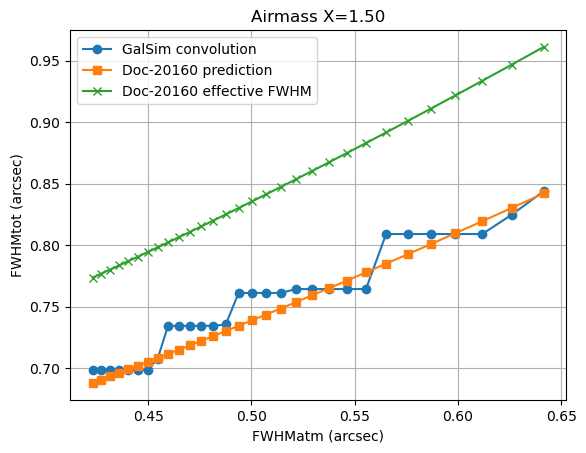

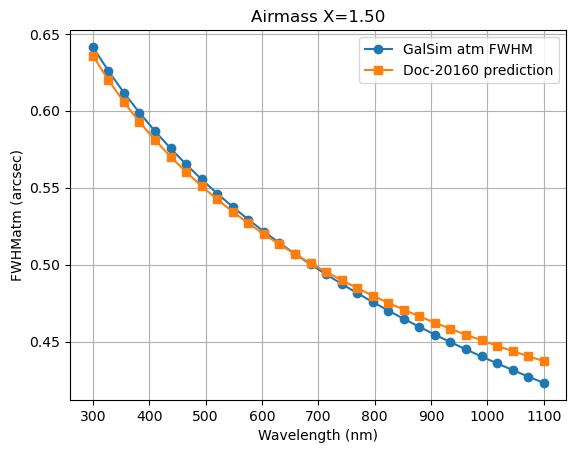

In [31]:
# Iterate over wavelengths to check 4.3/4 relationship

FWHM500 = fwhm_atm_analytic(500, r0_m, L0_m)

lams = np.linspace(300, 1100, 30)


fwhm_atms = []
fwhm_tots = []

for lam in lams:
    r0_scaled = r0_m * X**(-0.6) * (lam/500)**(6/5)
    fwhm_atm = fwhm_atm_analytic(lam, r0_scaled, L0_m)
    fwhm_atms.append(fwhm_atm_analytic(lam, r0_scaled, L0_m))

    atm_psf_ = galsim.VonKarman(lam=lam, r0=r0_scaled, L0=L0_m)

    fwhm_sys = fwhm_sys0 * X**0.6 
    sys_psf_ = galsim.Gaussian(fwhm=fwhm_sys)

    total_psf_ = galsim.Convolve([atm_psf_, sys_psf_])
    fwhm_tot = measure_fwhm(total_psf_, npix = npix, scale = scale) 
    fwhm_tots.append(fwhm_tot)


fwhm_effs = 1.16 * np.sqrt(np.array(fwhm_sys)**2 + 1.04 * np.array(fwhm_atms)**2)
fwhm_preds = 0.822 * fwhm_effs + 0.052
    
plt.plot(fwhm_atms, fwhm_tots, 'o-', label='GalSim convolution')
plt.plot(fwhm_atms, fwhm_preds, 's-', label='Doc-20160 prediction')
plt.plot(fwhm_atms, fwhm_effs, 'x-', label='Doc-20160 effective FWHM')
plt.xlabel('FWHMatm (arcsec)')
plt.ylabel('FWHMtot (arcsec)')
plt.title(f'Airmass X={X:.2f}')
plt.legend()
plt.grid()
plt.show()
plt.close()

fwhm_atms_pred = FWHM500 * (lams/500)**(-0.288) * X**(0.6372) 
plt.plot(lams, fwhm_atms, 'o-', label='GalSim atm FWHM')
plt.plot(lams, fwhm_atms_pred, 's-', label='Doc-20160 prediction')
plt.xlabel('Wavelength (nm)')
plt.ylabel('FWHMatm (arcsec)')
plt.title(f'Airmass X={X:.2f}')
plt.legend()
plt.grid()
plt.show()  

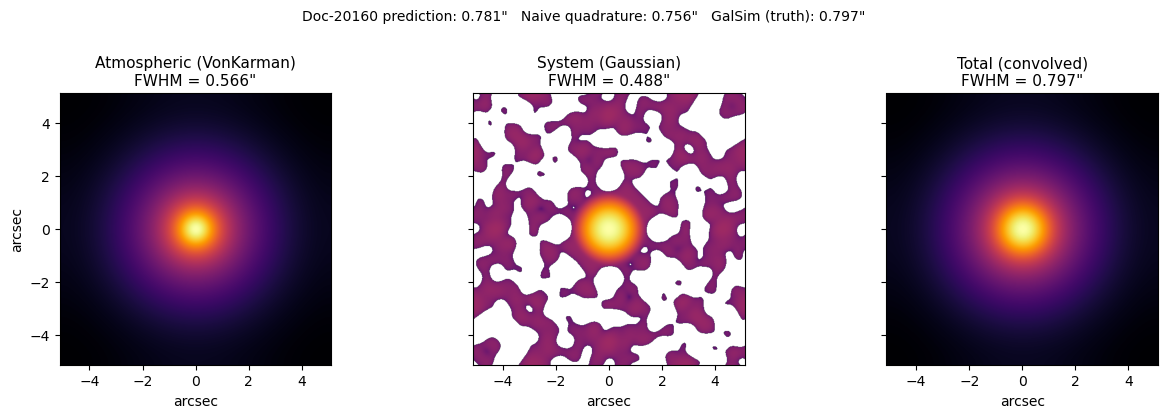

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

profiles = [
    (atm_psf,   f"Atmospheric (VonKarman)\nFWHM = {fwhm_atm_galsim:.3f}\""),
    (sys_psf,   f"System (Gaussian)\nFWHM = {fwhm_sys_galsim:.3f}\""),
    (total_psf, f"Total (convolved)\nFWHM = {fwhm_tot_galsim:.3f}\""),
]

for ax, (psf, title) in zip(axes, profiles):
    img = psf.drawImage(nx=npix, ny=npix, scale=scale).array
    extent = npix * scale / 2
    ax.imshow(img, origin='lower', extent=[-extent, extent, -extent, extent],
              cmap='inferno', norm=plt.matplotlib.colors.LogNorm())
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('arcsec')

axes[0].set_ylabel('arcsec')
plt.suptitle(
    f"Doc-20160 prediction: {fwhm_tot_pred:.3f}\"   "
    f"Naive quadrature: {fwhm_quad:.3f}\"   "
    f"GalSim (truth): {fwhm_tot_galsim:.3f}\"",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

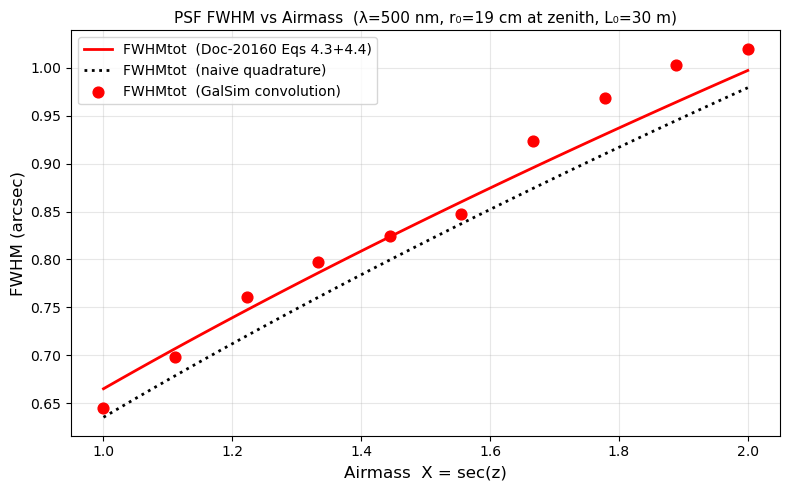

In [33]:
# --- Airmass sweep: X from 1.0 (zenith) to 2.0 (z ≈ 60°) ---
X_arr = np.linspace(1.0, 2.0, 40)
lam = 300
fwhm_atm_sweep = np.zeros(len(X_arr))
fwhm_sys_sweep = np.zeros(len(X_arr))
fwhm_tot_paper = np.zeros(len(X_arr))
fwhm_tot_quad  = np.zeros(len(X_arr))

for i, Xi in enumerate(X_arr):
    r0_x = r0_m * Xi**(-0.6) * (lam/500)**(6/5)        # Eq 3.2
    fa   = fwhm_atm_analytic(lam, r0_x, L0_m)          # Eq 3.3
    fs   = fwhm_sys0 * Xi**0.6                          # Eq 3.6
    fe   = 1.16 * np.sqrt(fs**2 + 1.04 * fa**2)        # Eq 4.3
    fwhm_atm_sweep[i] = fa
    fwhm_sys_sweep[i] = fs
    fwhm_tot_paper[i] = 0.822 * fe + 0.052             # Eq 4.4
    fwhm_tot_quad[i]  = np.sqrt(fa**2 + fs**2)

# GalSim validation at 5 airmass values
X_gs = np.linspace(1, 2, 10)# [1.0, 1.2, 1.4, 1.7, 2.0]
fwhm_gs = []
for Xi in X_gs:
    ap = galsim.VonKarman(lam=lam, r0=r0_m * Xi**(-0.6) * (lam/500)**(6/5), L0=L0_m)
    sp = galsim.Gaussian(fwhm=fwhm_sys0 * Xi**0.6)
    fwhm_gs.append(measure_fwhm(galsim.Convolve([ap, sp]), npix=npix, scale=scale))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
# ax.plot(X_arr, fwhm_atm_sweep, 'b--', lw=1.5, label='FWHMatm  (Eq 3.3, VonKarman)')
# ax.plot(X_arr, fwhm_sys_sweep, 'g--', lw=1.5, label='FWHMsys  (Eq 3.6, Gaussian)')
ax.plot(X_arr, fwhm_tot_paper, 'r-',  lw=2,   label='FWHMtot  (Doc-20160 Eqs 4.3+4.4)')
ax.plot(X_arr, fwhm_tot_quad,  'k:',  lw=2,   label='FWHMtot  (naive quadrature)')
ax.scatter(X_gs, fwhm_gs, c='red', zorder=5, s=60, label='FWHMtot  (GalSim convolution)')

ax.set_xlabel('Airmass  X = sec(z)', fontsize=12)
ax.set_ylabel('FWHM (arcsec)', fontsize=12)
ax.set_title(f'PSF FWHM vs Airmass  (λ=500 nm, r₀={r0_m*100:.0f} cm at zenith, L₀={L0_m:.0f} m)',
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
fwhm500, fwhmgeom, fwhmeff = 0.38867996, 0.91271166, 1.04709448
alt = 27.25948211
X_ = 1/np.cos(np.radians(90 - alt))
lam_ = sys_eff_wavelengths['g']

fwhm_sys_ = fwhm_sys0 * X_**0.6
fwhm_atm_ = fwhm500 * (lam_/500)**(-0.3) * X_**(0.6) 

fwhm_eff_ = 1.16 * np.sqrt(fwhm_sys_**2 + 1.04 * fwhm_atm_**2)
fwhm_tot_ = 0.822 * fwhm_eff_ + 0.052

print(fwhm_eff_, fwhm_tot_)

In [ ]:
r0s = np.linspace(0.05, 0.4, 100)
fwhm_atms = [fwhm_atm_analytic(500, r0, L0_m) for r0 in r0s]

r0_func = interp1d(fwhm_atms, r0s)(0.42380787)
print(r0_func)


0.190035659984848


---
## Section 2: PSF with Differential Chromatic Refraction (DCR)

`galsim.ChromaticAtmosphere` convolves the VonKarman seeing with a wavelength-dependent
positional shift (DCR) along the zenith axis, and also applies wavelength-dependent seeing
(`FWHM ∝ λ^α`, α = −0.2). Integrating a flat SED over the bandpass weights each wavelength
equally, so the resulting image is the flux-weighted smear of all per-wavelength PSFs.

DCR is set along the **+y axis** (`parallactic_angle = 0`), so the total PSF should appear
elongated in y — visible as **negative e1** from the HSM measurement (Iyy > Ixx → e1 < 0).

In [74]:
# --- Restore reference parameters (lam / r0_scaled are overwritten in loops above) ---
X = 1.0

lam_ref    = sys_eff_wavelengths['g']              # 480.7 nm
r0_ref     = r0_m * X**(-0.6) * (lam_ref/500)**(6/5)
fwhm_sys_dcr = fwhm_sys0 * X**0.6

# g-band flat (top-hat) bandpass
blue_limit, red_limit = 400.0, 550.0              # nm
bandpass = galsim.Bandpass(lambda w: 1.0, wave_type='nm',
                           blue_limit=blue_limit, red_limit=red_limit)
sed = galsim.SED(lambda w: 1.0, wave_type='nm', flux_type='fphotons')
sed_source = galsim.DeltaFunction() * sed

# Zenith angle from airmass
zenith_angle_dcr = np.degrees(np.arccos(1.0 / X)) * galsim.degrees

# ChromaticAtmosphere: wavelength-dependent seeing + DCR along +y
atm_chromatic = galsim.ChromaticAtmosphere(
    base_obj      = galsim.VonKarman(lam=lam_ref, r0=r0_ref, L0=L0_m),
    base_wavelength   = lam_ref,
    zenith_angle      = zenith_angle_dcr,
    parallactic_angle = 0.0 * galsim.degrees,
    alpha             = -0.2,
)
sys_psf_dcr     = galsim.Gaussian(fwhm=fwhm_sys_dcr)
total_chromatic = galsim.Convolve([atm_chromatic, sys_psf_dcr])

atm_chromatic_PSF = galsim.Convolve([atm_chromatic, sed_source]).withFlux(1.0, bandpass)

total_chromatic_PSF = galsim.Convolve([total_chromatic, sed_source]).withFlux(1.0, bandpass)

# Draw by integrating flat SED over bandpass
scale_dcr = 0.02 /2
npix_dcr  = 512 /2

img_atm_chrom = atm_chromatic_PSF.drawImage(
    bandpass, nx=npix_dcr, ny=npix_dcr, scale=scale_dcr)
img_sys_dcr   = sys_psf_dcr.drawImage(
    nx=npix_dcr, ny=npix_dcr, scale=scale_dcr)
img_tot_chrom = total_chromatic_PSF.drawImage(
    bandpass, nx=npix_dcr, ny=npix_dcr, scale=scale_dcr)

print(f"Reference wavelength : {lam_ref:.1f} nm")
print(f"Bandpass             : {blue_limit:.0f}–{red_limit:.0f} nm  (flat SED)")
print(f"Zenith angle         : {np.degrees(np.arccos(1.0/X)):.1f}°  (X = {X:.2f})")
print(f"r0 at ref wavelength : {r0_ref*100:.2f} cm")
print(f"FWHMatm (analytic)   : {fwhm_atm_analytic(lam_ref, r0_ref, L0_m):.4f} arcsec")
print(f"FWHMsys              : {fwhm_sys_dcr:.4f} arcsec")

Reference wavelength : 480.7 nm
Bandpass             : 400–550 nm  (flat SED)
Zenith angle         : 0.0°  (X = 1.00)
r0 at ref wavelength : 18.12 cm
FWHMatm (analytic)   : 0.4292 arcsec
FWHMsys              : 0.3986 arcsec


In [75]:
# Image-based FWHM helpers (chromatic drawImage returns a galsim.Image directly)
def fwhm_radial_img(img):
    arr = img.array
    s   = img.scale
    cy, cx = np.unravel_index(arr.argmax(), arr.shape)
    y, x   = np.indices(arr.shape)
    r      = np.sqrt((x - cx)**2 + (y - cy)**2) * s
    order  = np.argsort(r.ravel())
    r_s    = r.ravel()[order]
    v_s    = (arr.ravel() / arr.max())[order]
    return 2.0 * np.interp(0.5, v_s[::-1], r_s[::-1])

def fwhm_hsm_img(img):
    result = galsim.hsm.FindAdaptiveMom(img)
    fwhm   = 2.0 * np.sqrt(2.0 * np.log(2.0)) * result.moments_sigma * img.scale
    return fwhm, result.observed_shape.e1, result.observed_shape.e2

# Measure all three PSFs
fwhm_atm_r,                     = [fwhm_radial_img(img_atm_chrom)]
fwhm_sys_r,                     = [fwhm_radial_img(img_sys_dcr)]
fwhm_tot_r,                     = [fwhm_radial_img(img_tot_chrom)]
fwhm_atm_h, e1_atm, e2_atm      = fwhm_hsm_img(img_atm_chrom)
fwhm_sys_h, e1_sys, e2_sys      = fwhm_hsm_img(img_sys_dcr)
fwhm_tot_h, e1_tot, e2_tot      = fwhm_hsm_img(img_tot_chrom)

# Reference: achromatic total PSF from Section 1 (same lam_ref, same X)
atm_ref = galsim.VonKarman(lam=lam_ref, r0=r0_ref, L0=L0_m)
tot_ref = galsim.Convolve([atm_ref, sys_psf_dcr])
fwhm_ref_r               = measure_fwhm(tot_ref,   npix=npix_dcr, scale=scale_dcr)
fwhm_ref_h, e1_ref, e2_ref = measure_fwhm_hsm(tot_ref, npix=npix_dcr, scale=scale_dcr)

w = 34
print(f"{'':>{w}s}  {'radial':>8}  {'HSM':>8}  {'e1':>8}  {'e2':>8}")
print("-" * (w + 40))
print(f"{'FWHMatm  (chromatic VonKarman)':>{w}s}  {fwhm_atm_r:8.4f}  {fwhm_atm_h:8.4f}  {e1_atm:+8.4f}  {e2_atm:+8.4f}")
print(f"{'FWHMsys  (Gaussian)':>{w}s}  {fwhm_sys_r:8.4f}  {fwhm_sys_h:8.4f}  {e1_sys:+8.4f}  {e2_sys:+8.4f}")
print("-" * (w + 40))
print(f"{'FWHMtot  (with DCR)':>{w}s}  {fwhm_tot_r:8.4f}  {fwhm_tot_h:8.4f}  {e1_tot:+8.4f}  {e2_tot:+8.4f}")
print(f"{'FWHMtot  (no DCR, reference)':>{w}s}  {fwhm_ref_r:8.4f}  {fwhm_ref_h:8.4f}  {e1_ref:+8.4f}  {e2_ref:+8.4f}")
print("-" * (w + 40))
print(f"{'DCR broadening  (radial)':>{w}s}  {fwhm_tot_r - fwhm_ref_r:+8.4f} arcsec")
print(f"{'DCR broadening  (HSM)':>{w}s}  {fwhm_tot_h - fwhm_ref_h:+8.4f} arcsec")

                                      radial       HSM        e1        e2
--------------------------------------------------------------------------
    FWHMatm  (chromatic VonKarman)    0.4427    0.4692   +0.0000   -0.0000
               FWHMsys  (Gaussian)    0.3863    0.3987   -0.0000   -0.0000
--------------------------------------------------------------------------
               FWHMtot  (with DCR)    0.6161    0.6426   -0.0000   +0.0000
      FWHMtot  (no DCR, reference)    0.6161    0.6415   +0.0000   +0.0000
--------------------------------------------------------------------------
          DCR broadening  (radial)   +0.0000 arcsec
             DCR broadening  (HSM)   +0.0011 arcsec


/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_60169/389210915.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


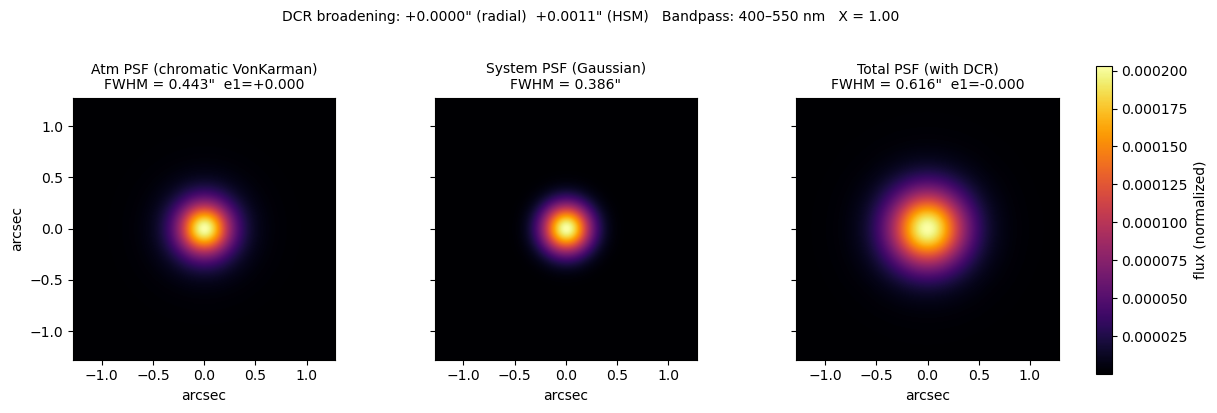

In [76]:
# --- Colorbar limits (fractions of the global peak across all three images) ---
vmin_frac = 1e-4   # lower clip; raise (e.g. 1e-3) to hide faint wings
vmax_frac = 1.0    # upper clip; lower (e.g. 0.1) to saturate the peak

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

imgs = [
    (img_atm_chrom, f"Atm PSF (chromatic VonKarman)\nFWHM = {fwhm_atm_r:.3f}\"  e1={e1_atm:+.3f}"),
    (img_sys_dcr,   f"System PSF (Gaussian)\nFWHM = {fwhm_sys_r:.3f}\""),
    (img_tot_chrom, f"Total PSF (with DCR)\nFWHM = {fwhm_tot_r:.3f}\"  e1={e1_tot:+.3f}"),
]

global_peak = max(img.array.max() for img, _ in imgs)
norm = plt.matplotlib.colors.LogNorm(
    vmin=global_peak * vmin_frac,
    vmax=global_peak * vmax_frac,
)

for ax, (img, title) in zip(axes, imgs):
    arr    = img.array
    extent = npix_dcr * scale_dcr / 2
    im = ax.imshow(arr, origin='lower', extent=[-extent, extent, -extent, extent],
                   cmap='inferno') #, norm=norm)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('arcsec')

axes[0].set_ylabel('arcsec')
fig.colorbar(im, ax=axes, label='flux (normalized)', fraction=0.05, pad=-0.25, location = 'right')
plt.suptitle(
    f"DCR broadening: {fwhm_tot_r - fwhm_ref_r:+.4f}\" (radial)  "
    f"{fwhm_tot_h - fwhm_ref_h:+.4f}\" (HSM)   "
    f"Bandpass: {blue_limit:.0f}–{red_limit:.0f} nm   X = {X:.2f}",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.show()